# Algoritmo de Euler-Maruyama

In [1]:
import torch
import matplotlib.pyplot as plt

In [17]:
class EulerMaruyama:

    def __init__(self, f, g):
        self.f = f
        self.g = g

    def simulate(self, x0, T, dt=0.01):
        t = 0
        x = x0.item() if isinstance(x0, torch.Tensor) else x0
        x_list = [x]

        while t < T:
            dw = torch.randn(1).item() * (dt**0.5)
            x = x + dt * self.f(x, t) + self.g(x, t) * dw
            x_list.append(x)
            t += dt

        return x_list

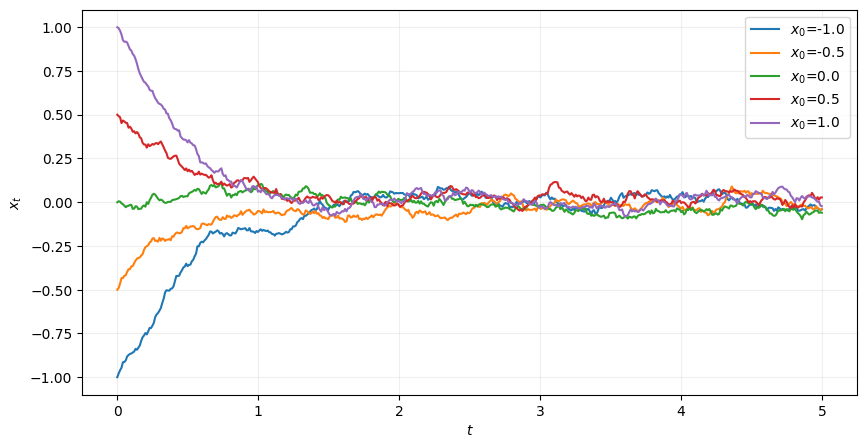

In [19]:
def f(x, t):
    return -2 * x

def g(x, t):
    return 0.1

euler_maruyama = EulerMaruyama(f, g)
T = 5

plt.figure(figsize=(10,5))
for x0 in torch.linspace(-1, 1, 5):
    x = euler_maruyama.simulate(x0, T)
    t = torch.linspace(0,T, len(x))
    plt.plot(t, x, label=rf'$x_0$={x0}')

plt.xlabel(r'$t$')
plt.ylabel(r'$x_t$')
plt.legend()
plt.grid(alpha=0.2)
plt.show()